## Cell 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
MODEL_DIR  = '/content/drive/MyDrive/insurance_fraud/models/'
PLOT_DIR   = '/content/drive/MyDrive/insurance_fraud/plots/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Cell 2 — Install & Import

In [ ]:
!pip install optuna lightgbm xgboost imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import json
import joblib
import time
warnings.filterwarnings('ignore')

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.model_selection     import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing       import StandardScaler
from sklearn.metrics             import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.inspection          import permutation_importance
from imblearn.over_sampling      import SMOTE
from imblearn.pipeline           import Pipeline as ImbPipeline

# ── Boosting models ────────────────────────────────────────────────────────────
import xgboost  as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress optuna logs

# ── Anomaly detection ─────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── Plot style ─────────────────────────────────────────────────────────────────
NAVY='#0D1B3E'; CARD='#132447'; ACCENT='#1DB8C4'
GREEN='#22C97A'; RED='#E84C4C'; YELLOW='#F5C842'
WHITE='#FFFFFF'; GRAY='#8BA3BF'; PURPLE='#C87EFF'; ORANGE='#FF8C42'
plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': CARD,
    'axes.labelcolor': WHITE, 'xtick.color': WHITE,
    'ytick.color': WHITE, 'text.color': WHITE,
    'axes.titlecolor': WHITE, 'axes.edgecolor': ACCENT,
    'grid.color': '#1D3557', 'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def save_plot(fig, name):
    fig.savefig(PLOT_DIR + name, dpi=150, bbox_inches='tight', facecolor=NAVY)
    print(f'  💾 {name}')

print('✅ All libraries imported.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 159.9 kB/s eta 0:00:00
✅ All libraries imported.


## Cell 3 — Load Data

In [ ]:
# Load engineered features from M3
data = pd.read_parquet(OUTPUT_DIR + 'train_features_engineered.parquet')

# Load feature column list
with open(OUTPUT_DIR + 'final_feature_columns.json') as f:
    feature_cols = json.load(f)

# Keep only features that exist in the dataset
feature_cols = [c for c in feature_cols if c in data.columns]

X = data[feature_cols].copy()
y = data['fraud_label'].copy()

# Ensure numeric, no nulls
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
X.replace([np.inf, -np.inf], 0, inplace=True)

print(f'✅ Dataset loaded')
print(f'   Features : {X.shape[1]}')
print(f'   Providers: {X.shape[0]:,}')
print(f'   Fraud rate: {y.mean()*100:.1f}%  ({y.sum():,} fraud / {(~y.astype(bool)).sum():,} legit)')

✅ Dataset loaded
   Features : 74
   Providers: 5,410
   Fraud rate: 9.4%  (506 fraud / 4,904 legit)


## Cell 4 — Train / Validation Split + SMOTE

In [ ]:
# Stratified split — preserves fraud ratio in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train set : {X_train.shape[0]:,} providers  |  fraud={y_train.mean()*100:.1f}%')
print(f'Val   set : {X_val.shape[0]:,} providers  |  fraud={y_val.mean()*100:.1f}%')

# Apply SMOTE ONLY on training set — NEVER on validation (would leak)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE:')
print(f'  Train set: {X_train_sm.shape[0]:,} providers  |  fraud={y_train_sm.mean()*100:.1f}%')
print(f'  Val   set: {X_val.shape[0]:,} providers  |  fraud={y_val.mean()*100:.1f}%  (unchanged)')

# Scale features for Logistic Regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_val_scaled   = scaler.transform(X_val)
joblib.dump(scaler, MODEL_DIR + 'scaler.pkl')
print('\n✅ Scaler saved.')

Train set : 4,328 providers  |  fraud=9.4%
Val   set : 1,082 providers  |  fraud=9.3%

After SMOTE:
  Train set: 7,846 providers  |  fraud=50.0%
  Val   set: 1,082 providers  |  fraud=9.3%  (unchanged)

✅ Scaler saved.


## Cell 5 — Evaluation Helper

In [ ]:
def evaluate_model(name, model, X_val, y_val, threshold=0.5, use_proba=True):
    """
    Evaluates a trained classifier and returns a metrics dict.
    Prints a clean summary table.
    """
    if use_proba:
        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred  = (y_proba >= threshold).astype(int)
        auc     = roc_auc_score(y_val, y_proba)
        ap      = average_precision_score(y_val, y_proba)
    else:
        y_pred  = model.predict(X_val)
        y_proba = y_pred
        auc     = roc_auc_score(y_val, y_pred)
        ap      = average_precision_score(y_val, y_pred)

    metrics = {
        'Model'    : name,
        'AUC-ROC'  : round(auc,  4),
        'Avg Prec' : round(ap,   4),
        'F1'       : round(f1_score(y_val, y_pred),        4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall'   : round(recall_score(y_val, y_pred),    4),
        'Accuracy' : round(accuracy_score(y_val, y_pred),  4),
        'Threshold': threshold,
        '_proba'   : y_proba,
        '_pred'    : y_pred,
    }

    print(f'\n  ┌─ {name} ─────────────────────────────────')
    print(f'  │  AUC-ROC  : {metrics["AUC-ROC"]:.4f}')
    print(f'  │  Avg Prec : {metrics["Avg Prec"]:.4f}')
    print(f'  │  F1-Score : {metrics["F1"]:.4f}')
    print(f'  │  Precision: {metrics["Precision"]:.4f}')
    print(f'  │  Recall   : {metrics["Recall"]:.4f}')
    print(f'  │  Accuracy : {metrics["Accuracy"]:.4f}')
    print(f'  └─ Threshold: {threshold}')
    return metrics


def find_best_threshold(model, X_val, y_val):
    """Find threshold that maximises F1 on validation set."""
    y_proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 81)
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        f1 = f1_score(y_val, (y_proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2), round(best_f1, 4)


all_metrics = []   # Collect all model results here
print('✅ Evaluation helpers defined.')

✅ Evaluation helpers defined.


## Cell 6 — Model 1: Logistic Regression (Baseline)

In [ ]:
print('🔄 Training Logistic Regression (baseline)...')
t0 = time.time()

lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train_sm)
print(f'   Trained in {time.time()-t0:.1f}s')

best_t_lr, _ = find_best_threshold(lr, X_val_scaled, y_val)
m_lr = evaluate_model('Logistic Regression', lr, X_val_scaled, y_val, threshold=best_t_lr)
all_metrics.append(m_lr)

joblib.dump(lr, MODEL_DIR + 'model_logreg.pkl')
print('  💾 model_logreg.pkl saved')

🔄 Training Logistic Regression (baseline)...
   Trained in 0.6s

  ┌─ Logistic Regression ─────────────────────────────────
  │  AUC-ROC  : 0.9585
  │  Avg Prec : 0.7914
  │  F1-Score : 0.7273
  │  Precision: 0.7907
  │  Recall   : 0.6733
  │  Accuracy : 0.9529
  └─ Threshold: 0.82
  💾 model_logreg.pkl saved


## Cell 7 — Model 2: Random Forest (Baseline Tree)

In [ ]:
print('🔄 Training Random Forest...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
print(f'   Trained in {time.time()-t0:.1f}s')

best_t_rf, _ = find_best_threshold(rf, X_val, y_val)
m_rf = evaluate_model('Random Forest', rf, X_val, y_val, threshold=best_t_rf)
all_metrics.append(m_rf)

joblib.dump(rf, MODEL_DIR + 'model_random_forest.pkl')
print('  💾 model_random_forest.pkl saved')

🔄 Training Random Forest...
   Trained in 6.0s

  ┌─ Random Forest ─────────────────────────────────
  │  AUC-ROC  : 0.9680
  │  Avg Prec : 0.7758
  │  F1-Score : 0.7156
  │  Precision: 0.6667
  │  Recall   : 0.7723
  │  Accuracy : 0.9427
  └─ Threshold: 0.57
  💾 model_random_forest.pkl saved


## Cell 8 — Model 3: XGBoost with Optuna Tuning

In [ ]:
print('🔄 Tuning XGBoost with Optuna (50 trials — takes 2-4 min)...')

scale_pos = int((y_train_sm == 0).sum() / (y_train_sm == 1).sum())

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 4, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'scale_pos_weight' : scale_pos,
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'eval_metric'      : 'auc',
        'use_label_encoder': False,
    }
    model = xgb.XGBClassifier(**params)
    # 3-fold CV for speed
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'\n  Best XGBoost CV AUC: {study_xgb.best_value:.4f}')
print(f'  Best params: {study_xgb.best_params}')

# Train final XGBoost with best params on full train set
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    'scale_pos_weight': scale_pos,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'eval_metric': 'auc',
    'use_label_encoder': False,
})

xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_t_xgb, _ = find_best_threshold(xgb_model, X_val, y_val)
m_xgb = evaluate_model('XGBoost (tuned)', xgb_model, X_val, y_val, threshold=best_t_xgb)
all_metrics.append(m_xgb)

joblib.dump(xgb_model, MODEL_DIR + 'model_xgboost.pkl')
print('  💾 model_xgboost.pkl saved')

🔄 Tuning XGBoost with Optuna (50 trials — takes 2-4 min)...


  0%|          | 0/50 [00:00<?, ?it/s]


  Best XGBoost CV AUC: 0.9955
  Best params: {'n_estimators': 432, 'max_depth': 8, 'learning_rate': 0.07213285431530564, 'subsample': 0.8182282987054682, 'colsample_bytree': 0.6501886032252533, 'min_child_weight': 1, 'gamma': 0.05095280591222019, 'reg_alpha': 8.407218793937144e-05, 'reg_lambda': 1.2772123932719608}

  ┌─ XGBoost (tuned) ─────────────────────────────────
  │  AUC-ROC  : 0.9683
  │  Avg Prec : 0.8060
  │  F1-Score : 0.7451
  │  Precision: 0.7379
  │  Recall   : 0.7525
  │  Accuracy : 0.9519
  └─ Threshold: 0.51
  💾 model_xgboost.pkl saved


## Cell 9 — Model 4: LightGBM with Optuna Tuning

In [ ]:
print('🔄 Tuning LightGBM with Optuna (50 trials — takes 2-3 min)...')

def lgbm_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'class_weight'     : 'balanced',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : -1,
    }
    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'\n  Best LightGBM CV AUC: {study_lgbm.best_value:.4f}')
print(f'  Best params: {study_lgbm.best_params}')

best_lgbm_params = study_lgbm.best_params.copy()
best_lgbm_params.update({
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
})

lgbm_model = lgb.LGBMClassifier(**best_lgbm_params)
lgbm_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

best_t_lgbm, _ = find_best_threshold(lgbm_model, X_val, y_val)
m_lgbm = evaluate_model('LightGBM (tuned)', lgbm_model, X_val, y_val, threshold=best_t_lgbm)
all_metrics.append(m_lgbm)

joblib.dump(lgbm_model, MODEL_DIR + 'model_lightgbm.pkl')
print('  💾 model_lightgbm.pkl saved')

🔄 Tuning LightGBM with Optuna (50 trials — takes 2-3 min)...


  0%|          | 0/50 [00:00<?, ?it/s]


  Best LightGBM CV AUC: 0.9967
  Best params: {'n_estimators': 710, 'max_depth': 10, 'learning_rate': 0.07487485123990609, 'num_leaves': 118, 'subsample': 0.9366802208095956, 'colsample_bytree': 0.7334804848394666, 'min_child_samples': 7, 'reg_alpha': 1.978904274769893e-05, 'reg_lambda': 3.5891961790541357e-06}

  ┌─ LightGBM (tuned) ─────────────────────────────────
  │  AUC-ROC  : 0.9637
  │  Avg Prec : 0.7982
  │  F1-Score : 0.7200
  │  Precision: 0.7273
  │  Recall   : 0.7129
  │  Accuracy : 0.9482
  └─ Threshold: 0.6
  💾 model_lightgbm.pkl saved


## Cell 10 — Model 5: Isolation Forest (Unsupervised Anomaly Layer)

In [ ]:
print('🔄 Training Isolation Forest (unsupervised anomaly detection)...')
t0 = time.time()

# Train ONLY on non-fraud samples — learns what "normal" looks like
X_train_legit = X_train_sm[y_train_sm == 0]

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.10,   # Expected ~10% anomaly rate
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_legit)
print(f'   Trained in {time.time()-t0:.1f}s')

# Predict on validation: -1 = anomaly, 1 = normal
iso_pred_raw = iso_forest.predict(X_val)        # -1 or 1
iso_scores   = iso_forest.score_samples(X_val)  # More negative = more anomalous

# Convert: -1 → 1 (fraud), 1 → 0 (normal)
iso_pred_binary = (iso_pred_raw == -1).astype(int)

# Normalise anomaly scores to 0-1 probability-like range
iso_scores_norm = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min() + 1e-9)
iso_scores_norm = 1 - iso_scores_norm  # Invert: higher = more anomalous

iso_auc = roc_auc_score(y_val, iso_scores_norm)
iso_f1  = f1_score(y_val, iso_pred_binary)

print(f'\n  ┌─ Isolation Forest ──────────────────────')
print(f'  │  AUC-ROC  : {iso_auc:.4f}  (unsupervised — no labels used)')
print(f'  │  F1-Score : {iso_f1:.4f}')
print(f'  │  Anomalies detected: {iso_pred_binary.sum()} / {len(iso_pred_binary)}')
print(f'  └─ Used as extra feature in ensemble')

# Save the anomaly score as an extra feature for the ensemble
iso_m = {
    'Model': 'Isolation Forest', 'AUC-ROC': round(iso_auc,4),
    'Avg Prec': round(average_precision_score(y_val, iso_scores_norm),4),
    'F1': round(iso_f1,4), 'Precision': round(precision_score(y_val, iso_pred_binary),4),
    'Recall': round(recall_score(y_val, iso_pred_binary),4),
    'Accuracy': round(accuracy_score(y_val, iso_pred_binary),4),
    'Threshold': 0.5, '_proba': iso_scores_norm, '_pred': iso_pred_binary
}
all_metrics.append(iso_m)

joblib.dump(iso_forest, MODEL_DIR + 'model_isolation_forest.pkl')
print('  💾 model_isolation_forest.pkl saved')

🔄 Training Isolation Forest (unsupervised anomaly detection)...
   Trained in 1.0s

  ┌─ Isolation Forest ──────────────────────
  │  AUC-ROC  : 0.9404  (unsupervised — no labels used)
  │  F1-Score : 0.5570
  │  Anomalies detected: 197 / 1082
  └─ Used as extra feature in ensemble
  💾 model_isolation_forest.pkl saved


## Cell 11 — Model 6: Soft Voting Ensemble (XGBoost + LightGBM + Random Forest)

In [ ]:
print('🔄 Building Soft Voting Ensemble (XGB + LGBM + RF)...')

# Soft voting: average the predicted probabilities from all 3 models
# XGBoost and LightGBM get higher weight (they tuned better)
ensemble = VotingClassifier(
    estimators=[
        ('xgb',  xgb_model),
        ('lgbm', lgbm_model),
        ('rf',   rf),
    ],
    voting='soft',
    weights=[3, 3, 1]   # XGB and LGBM weighted 3x higher than RF
)

# VotingClassifier needs to be fit — but our models are already fit
# Use a workaround: manually average probabilities
xgb_proba  = xgb_model.predict_proba(X_val)[:, 1]
lgbm_proba = lgbm_model.predict_proba(X_val)[:, 1]
rf_proba   = rf.predict_proba(X_val)[:, 1]

# Weighted average
ensemble_proba = (3 * xgb_proba + 3 * lgbm_proba + 1 * rf_proba) / 7

# Find best threshold
thresholds = np.linspace(0.1, 0.9, 81)
best_f1, best_t_ens = 0, 0.5
for t in thresholds:
    f1 = f1_score(y_val, (ensemble_proba >= t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t_ens = f1, t

ensemble_pred = (ensemble_proba >= best_t_ens).astype(int)

ens_metrics = {
    'Model'    : 'Ensemble (XGB+LGBM+RF)',
    'AUC-ROC'  : round(roc_auc_score(y_val, ensemble_proba), 4),
    'Avg Prec' : round(average_precision_score(y_val, ensemble_proba), 4),
    'F1'       : round(f1_score(y_val, ensemble_pred), 4),
    'Precision': round(precision_score(y_val, ensemble_pred), 4),
    'Recall'   : round(recall_score(y_val, ensemble_pred), 4),
    'Accuracy' : round(accuracy_score(y_val, ensemble_pred), 4),
    'Threshold': round(best_t_ens, 2),
    '_proba'   : ensemble_proba,
    '_pred'    : ensemble_pred,
}
all_metrics.append(ens_metrics)

print(f'\n  ┌─ Ensemble (XGB + LGBM + RF) ─────────────')
print(f'  │  AUC-ROC  : {ens_metrics["AUC-ROC"]:.4f}  ← FINAL MODEL')
print(f'  │  Avg Prec : {ens_metrics["Avg Prec"]:.4f}')
print(f'  │  F1-Score : {ens_metrics["F1"]:.4f}')
print(f'  │  Precision: {ens_metrics["Precision"]:.4f}')
print(f'  │  Recall   : {ens_metrics["Recall"]:.4f}')
print(f'  │  Accuracy : {ens_metrics["Accuracy"]:.4f}')
print(f'  └─ Best threshold: {best_t_ens:.2f}')

# Save ensemble config
ensemble_config = {
    'models'    : ['model_xgboost.pkl', 'model_lightgbm.pkl', 'model_random_forest.pkl'],
    'weights'   : [3, 3, 1],
    'threshold' : round(best_t_ens, 2),
    'auc_roc'   : ens_metrics['AUC-ROC'],
    'f1'        : ens_metrics['F1'],
}
with open(MODEL_DIR + 'ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)
print('  💾 ensemble_config.json saved')

🔄 Building Soft Voting Ensemble (XGB + LGBM + RF)...

  ┌─ Ensemble (XGB + LGBM + RF) ─────────────
  │  AUC-ROC  : 0.9704  ← FINAL MODEL
  │  Avg Prec : 0.8118
  │  F1-Score : 0.7213
  │  Precision: 0.8049
  │  Recall   : 0.6535
  │  Accuracy : 0.9529
  └─ Best threshold: 0.73
  💾 ensemble_config.json saved


## Cell 12 — Model Comparison Table

In [ ]:
display_cols = ['Model', 'AUC-ROC', 'Avg Prec', 'F1', 'Precision', 'Recall', 'Accuracy', 'Threshold']
results_df = pd.DataFrame([{k: m[k] for k in display_cols} for m in all_metrics])
results_df = results_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('\n' + '='*85)
print('  MODEL COMPARISON — VALIDATION SET RESULTS')
print('='*85)
print(results_df.to_string(index=False))
print('='*85)

best_model_name = results_df.iloc[0]['Model']
print(f'\n🏆 Best model: {best_model_name}')
print(f'   AUC-ROC : {results_df.iloc[0]["AUC-ROC"]}')
print(f'   F1-Score: {results_df.iloc[0]["F1"]}')

# Save results
results_df.to_json(MODEL_DIR + 'model_comparison.json', orient='records', indent=2)
print('\n  💾 model_comparison.json saved')


  MODEL COMPARISON — VALIDATION SET RESULTS
                 Model  AUC-ROC  Avg Prec     F1  Precision  Recall  Accuracy  Threshold
Ensemble (XGB+LGBM+RF)   0.9704    0.8118 0.7213     0.8049  0.6535    0.9529       0.73
       XGBoost (tuned)   0.9683    0.8060 0.7451     0.7379  0.7525    0.9519       0.51
         Random Forest   0.9680    0.7758 0.7156     0.6667  0.7723    0.9427       0.57
      LightGBM (tuned)   0.9637    0.7982 0.7200     0.7273  0.7129    0.9482       0.60
   Logistic Regression   0.9585    0.7914 0.7273     0.7907  0.6733    0.9529       0.82
      Isolation Forest   0.9404    0.6726 0.5570     0.4213  0.8218    0.8780       0.50

🏆 Best model: Ensemble (XGB+LGBM+RF)
   AUC-ROC : 0.9704
   F1-Score: 0.7213

  💾 model_comparison.json saved


## Cell 13 — Plot: ROC Curves (All Models)

  💾 plot_M4_roc_pr_curves.png


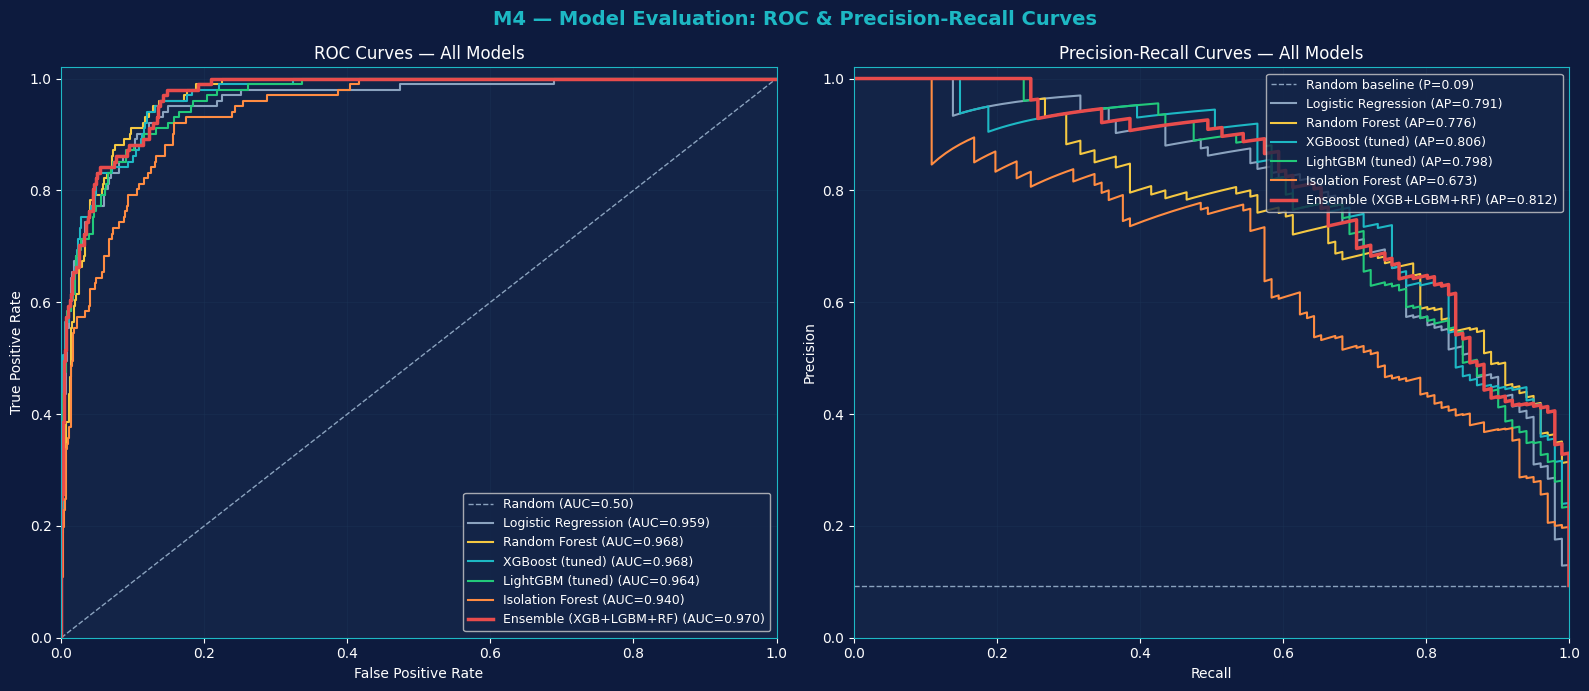

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('M4 — Model Evaluation: ROC & Precision-Recall Curves',
             fontsize=14, fontweight='bold', color=ACCENT)

model_colors = {
    'Logistic Regression'   : GRAY,
    'Random Forest'         : YELLOW,
    'XGBoost (tuned)'       : ACCENT,
    'LightGBM (tuned)'      : GREEN,
    'Isolation Forest'      : ORANGE,
    'Ensemble (XGB+LGBM+RF)': RED,
}

# ── ROC Curve ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot([0,1],[0,1], color=GRAY, linestyle='--', linewidth=1, label='Random (AUC=0.50)')

for m in all_metrics:
    fpr, tpr, _ = roc_curve(y_val, m['_proba'])
    color = model_colors.get(m['Model'], WHITE)
    lw    = 2.5 if 'Ensemble' in m['Model'] else 1.5
    ax.plot(fpr, tpr, color=color, linewidth=lw,
            label=f"{m['Model']} (AUC={m['AUC-ROC']:.3f})")

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.xaxis.grid(True); ax.yaxis.grid(True); ax.set_axisbelow(True)

# ── Precision-Recall Curve ────────────────────────────────────────────────────
ax = axes[1]
baseline_pr = y_val.mean()
ax.axhline(baseline_pr, color=GRAY, linestyle='--', linewidth=1,
           label=f'Random baseline (P={baseline_pr:.2f})')

for m in all_metrics:
    prec, rec, _ = precision_recall_curve(y_val, m['_proba'])
    color = model_colors.get(m['Model'], WHITE)
    lw    = 2.5 if 'Ensemble' in m['Model'] else 1.5
    ap    = m['Avg Prec']
    ax.plot(rec, prec, color=color, linewidth=lw,
            label=f"{m['Model']} (AP={ap:.3f})")

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.xaxis.grid(True); ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save_plot(fig, 'plot_M4_roc_pr_curves.png')
plt.show()

## Cell 14 — Plot: Confusion Matrices (Best 4 Models)

## Cell 15 — Plot: XGBoost Feature Importance (Top 25)

  💾 plot_M4_xgb_feature_importance.png


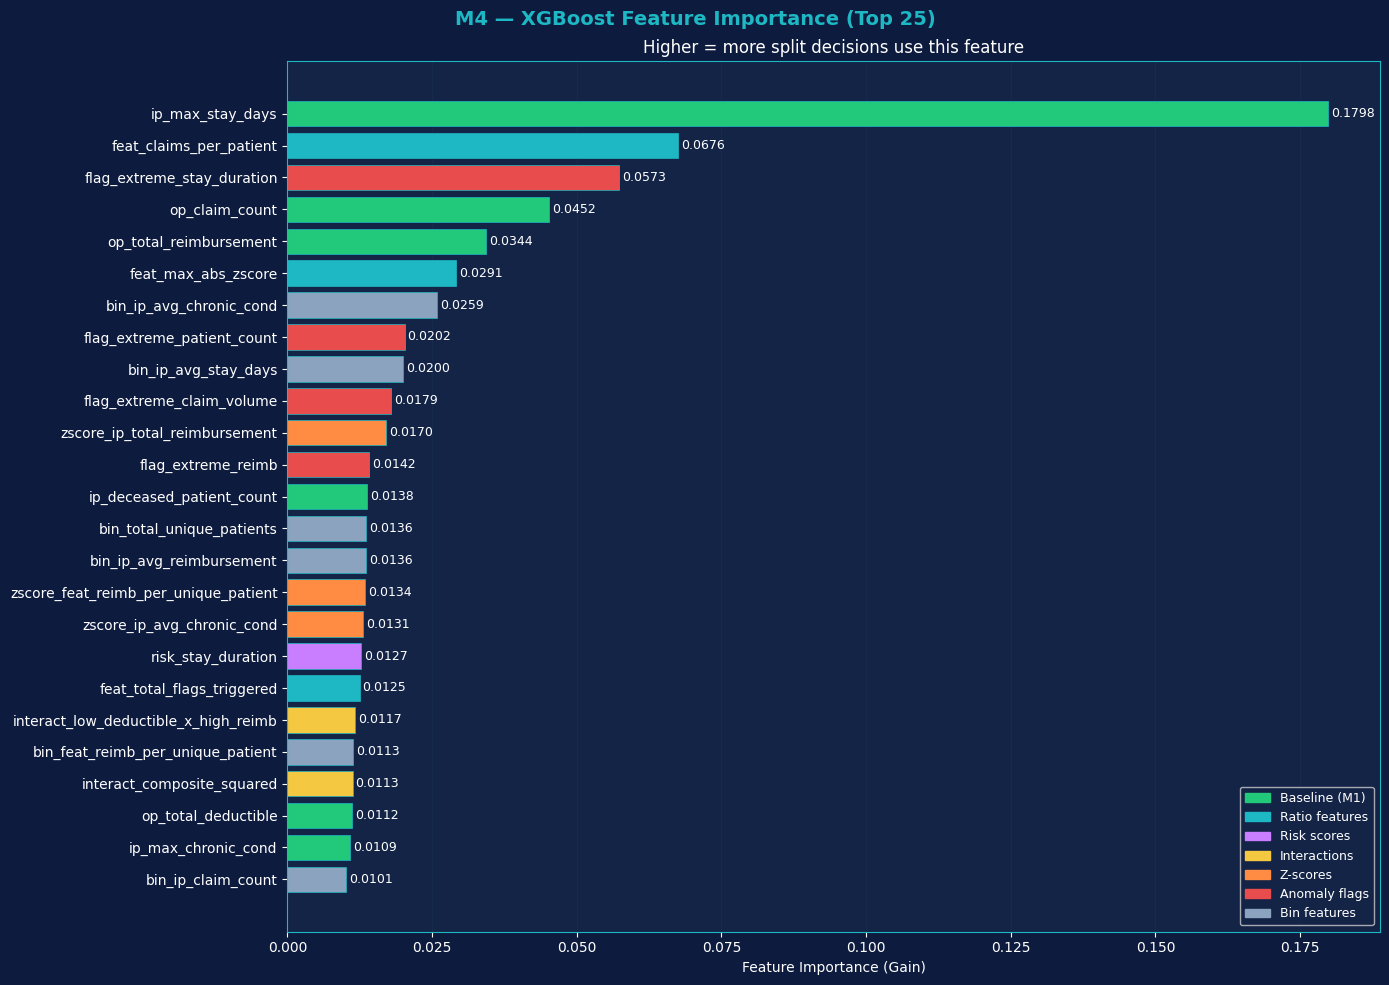

  💾 xgb_feature_importance.json saved


In [ ]:
# XGBoost has built-in feature importance (gain-based)
xgb_importance = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

top25 = xgb_importance.head(25)

# Color by feature group
def get_color(f):
    if f.startswith('risk_'):     return PURPLE
    if f.startswith('interact_'): return YELLOW
    if f.startswith('feat_'):     return ACCENT
    if f.startswith('flag_'):     return RED
    if f.startswith('zscore_'):   return ORANGE
    if f.startswith('bin_'):      return GRAY
    return GREEN

colors = [get_color(f) for f in top25['feature']]

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle('M4 — XGBoost Feature Importance (Top 25)',
             fontsize=14, fontweight='bold', color=ACCENT)

bars = ax.barh(top25['feature'][::-1],
               top25['importance'][::-1],
               color=colors[::-1],
               edgecolor=ACCENT, linewidth=0.5)

for bar, val in zip(bars, top25['importance'][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color=WHITE)

ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Higher = more split decisions use this feature')
ax.xaxis.grid(True); ax.set_axisbelow(True)

import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color=GREEN,  label='Baseline (M1)'),
    mpatches.Patch(color=ACCENT, label='Ratio features'),
    mpatches.Patch(color=PURPLE, label='Risk scores'),
    mpatches.Patch(color=YELLOW, label='Interactions'),
    mpatches.Patch(color=ORANGE, label='Z-scores'),
    mpatches.Patch(color=RED,    label='Anomaly flags'),
    mpatches.Patch(color=GRAY,   label='Bin features'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)

plt.tight_layout()
save_plot(fig, 'plot_M4_xgb_feature_importance.png')
plt.show()

# Save for M5 (XAI)
xgb_importance.to_json(MODEL_DIR + 'xgb_feature_importance.json',
                        orient='records', indent=2)
print('  💾 xgb_feature_importance.json saved')

## Cell 16 — Classification Report (Best Model)

In [ ]:
print('='*65)
print('  FINAL MODEL — DETAILED CLASSIFICATION REPORT')
print('  Model: Ensemble (XGBoost + LightGBM + Random Forest)')
print('='*65)
print(classification_report(
    y_val, ensemble_pred,
    target_names=['Legitimate (0)', 'Fraud (1)'],
    digits=4
))

print('\n📊 Threshold Analysis:')
print(f'   Best threshold (max F1): {best_t_ens:.2f}')
print(f'   At this threshold:')
print(f'     True Positives  (caught fraud)        : {((ensemble_pred==1) & (y_val==1)).sum()}')
print(f'     False Positives (wrongly flagged legit): {((ensemble_pred==1) & (y_val==0)).sum()}')
print(f'     False Negatives (missed fraud)         : {((ensemble_pred==0) & (y_val==1)).sum()}')
print(f'     True Negatives  (correct legit)        : {((ensemble_pred==0) & (y_val==0)).sum()}')

print('\n📌 Next: Open M5_XAI.ipynb for SHAP explainability')
print('='*65)

  FINAL MODEL — DETAILED CLASSIFICATION REPORT
  Model: Ensemble (XGBoost + LightGBM + Random Forest)
                precision    recall  f1-score   support

Legitimate (0)     0.9650    0.9837    0.9743       981
     Fraud (1)     0.8049    0.6535    0.7213       101

      accuracy                         0.9529      1082
     macro avg     0.8849    0.8186    0.8478      1082
  weighted avg     0.9501    0.9529    0.9506      1082


📊 Threshold Analysis:
   Best threshold (max F1): 0.73
   At this threshold:
     True Positives  (caught fraud)        : 66
     False Positives (wrongly flagged legit): 16
     False Negatives (missed fraud)         : 35
     True Negatives  (correct legit)        : 965

📌 Next: Open M5_XAI.ipynb for SHAP explainability


## Cell 17 — Save Everything to Drive

In [ ]:
print('💾 Final save — all model artifacts...')

# Save validation predictions for M5 (SHAP needs the val set)
val_predictions = pd.DataFrame({
    'y_true'          : y_val.values,
    'xgb_proba'       : xgb_proba,
    'lgbm_proba'      : lgbm_proba,
    'rf_proba'        : rf_proba,
    'ensemble_proba'  : ensemble_proba,
    'ensemble_pred'   : ensemble_pred,
    'iso_anomaly_score': iso_scores_norm,
})
val_predictions.to_parquet(MODEL_DIR + 'val_predictions.parquet', index=False)
print('  ✅ val_predictions.parquet')

# Save val feature matrix for SHAP
pd.DataFrame(X_val, columns=feature_cols).to_parquet(
    MODEL_DIR + 'X_val.parquet', index=False
)
print('  ✅ X_val.parquet')

# Save best threshold
model_metadata = {
    'best_model'       : 'Ensemble (XGB+LGBM+RF)',
    'best_threshold'   : round(best_t_ens, 2),
    'val_auc_roc'      : ens_metrics['AUC-ROC'],
    'val_f1'           : ens_metrics['F1'],
    'val_precision'    : ens_metrics['Precision'],
    'val_recall'       : ens_metrics['Recall'],
    'feature_count'    : len(feature_cols),
    'train_size_smote' : len(X_train_sm),
    'val_size'         : len(X_val),
}
with open(MODEL_DIR + 'model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print('  ✅ model_metadata.json')

print(f'\n🎉 All artifacts saved to: {MODEL_DIR}')
print('\n📁 Files in models/ folder:')
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(MODEL_DIR + f) / 1024
    print(f'  {f:<45} {size:>8.1f} KB')

print('\n📌 Next Steps:')
print('   → M5_XAI.ipynb        — SHAP explainability + investigator report')
print('   → M6_Document_UI.ipynb — Upload PDF claim → scan → fraud score')

💾 Final save — all model artifacts...
  ✅ val_predictions.parquet
  ✅ X_val.parquet
  ✅ model_metadata.json

🎉 All artifacts saved to: /content/drive/MyDrive/insurance_fraud/models/

📁 Files in models/ folder:
  X_val.parquet                                    242.4 KB
  ensemble_config.json                               0.2 KB
  model_comparison.json                              1.1 KB
  model_isolation_forest.pkl                      3020.5 KB
  model_lightgbm.pkl                               932.0 KB
  model_logreg.pkl                                   1.4 KB
  model_metadata.json                                0.2 KB
  model_random_forest.pkl                         9165.9 KB
  model_xgboost.pkl                               1327.6 KB
  scaler.pkl                                         4.4 KB
  val_predictions.parquet                           50.0 KB
  xgb_feature_importance.json                        5.7 KB

📌 Next Steps:
   → M5_XAI.ipynb        — SHAP explainability + invest